In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [56]:
df = pd.read_csv("telco_data.csv")
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [57]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66.0,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [59]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            6293 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   6043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       5543 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [61]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

In [62]:
yes_no_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "Churn"
]

In [63]:
df[yes_no_cols] = df[yes_no_cols].replace({
    "Yes": 1,
    "No": 0
})
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1.0,0,No phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34.0,1,No,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2.0,1,No,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45.0,0,No phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2.0,1,No,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24.0,1,Yes,DSL,1,...,1,1,1,1,One year,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,1,1,72.0,1,Yes,Fiber optic,0,...,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,1,1,11.0,0,No phone service,DSL,1,...,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,1,0,NaN,1,Yes,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.6,1


In [64]:
df["MultipleLines"].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [65]:
df["MultipleLines"] = df["MultipleLines"].map({
    'Yes': 1,
    'No':0,
    'No phone service': 0
})
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1.0,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34.0,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2.0,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45.0,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2.0,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24.0,1,1,DSL,1,...,1,1,1,1,One year,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,1,1,72.0,1,1,Fiber optic,0,...,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,1,1,11.0,0,0,DSL,1,...,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,1,0,NaN,1,1,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.6,1


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            6293 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   6043 non-null   str    
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   object 
 17  Paymen

In [67]:
df["InternetService"] = df["InternetService"].replace({
    'nan': df["InternetService"].mode()[0]
})

In [68]:
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1.0,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34.0,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2.0,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45.0,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2.0,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24.0,1,1,DSL,1,...,1,1,1,1,One year,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,1,1,72.0,1,1,Fiber optic,0,...,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,1,1,11.0,0,0,DSL,1,...,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,1,0,NaN,1,1,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.6,1


In [69]:
df = pd.get_dummies(
    df,
    columns=["InternetService"],
    drop_first=True,
    dtype=int
)
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,1,0,1.0,0,0,0,1,...,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,0,0
1,5575-GNVDE,Male,0,0,0,34.0,1,0,1,0,...,0,0,One year,0,Mailed check,56.95,1889.5,0,0,0
2,3668-QPYBK,Male,0,0,0,2.0,1,0,1,1,...,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,0,0
3,7795-CFOCW,Male,0,0,0,45.0,0,0,1,0,...,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,0,0
4,9237-HQITU,Female,0,0,0,2.0,1,0,0,0,...,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24.0,1,1,1,0,...,1,1,One year,1,Mailed check,84.80,1990.5,0,0,0
7039,2234-XADUH,Female,0,1,1,72.0,1,1,0,1,...,1,1,One year,1,Credit card (automatic),103.20,7362.9,0,1,0
7040,4801-JZAZL,Female,0,1,1,11.0,0,0,1,0,...,0,0,Month-to-month,1,Electronic check,29.60,346.45,0,0,0
7041,8361-LTMKD,Male,1,1,0,NaN,1,1,0,0,...,0,0,Month-to-month,1,Mailed check,74.40,306.6,1,1,0


In [70]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='str')

In [71]:
df.isnull().sum()

customerID                        0
gender                          750
SeniorCitizen                     0
Partner                        1000
Dependents                        0
tenure                         2500
PhoneService                      0
MultipleLines                     0
OnlineSecurity                    0
OnlineBackup                      0
DeviceProtection                  0
TechSupport                       0
StreamingTV                    1500
StreamingMovies                   0
Contract                          0
PaperlessBilling                  0
PaymentMethod                     0
MonthlyCharges                 1500
TotalCharges                      0
Churn                             0
InternetService_Fiber optic       0
InternetService_No                0
dtype: int64

In [72]:
for col in yes_no_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [73]:
df.isnull().sum()

customerID                        0
gender                          750
SeniorCitizen                     0
Partner                           0
Dependents                        0
tenure                         2500
PhoneService                      0
MultipleLines                     0
OnlineSecurity                    0
OnlineBackup                      0
DeviceProtection                  0
TechSupport                       0
StreamingTV                       0
StreamingMovies                   0
Contract                          0
PaperlessBilling                  0
PaymentMethod                     0
MonthlyCharges                 1500
TotalCharges                      0
Churn                             0
InternetService_Fiber optic       0
InternetService_No                0
dtype: int64

In [74]:
df['gender'] = df['gender'].map({
    'Male': 0, 'Female': 1
})

In [75]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

In [76]:
df["tenure"] = df["tenure"].fillna(df["tenure"].median())

In [77]:
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(df["MonthlyCharges"].mean())

In [78]:
df.isnull().sum()

customerID                     0
gender                         0
SeniorCitizen                  0
Partner                        0
Dependents                     0
tenure                         0
PhoneService                   0
MultipleLines                  0
OnlineSecurity                 0
OnlineBackup                   0
DeviceProtection               0
TechSupport                    0
StreamingTV                    0
StreamingMovies                0
Contract                       0
PaperlessBilling               0
PaymentMethod                  0
MonthlyCharges                 0
TotalCharges                   0
Churn                          0
InternetService_Fiber optic    0
InternetService_No             0
dtype: int64

In [79]:
display(df.corr(numeric_only=True))

,gender,SeniorCitizen,tenure,MultipleLines,MonthlyCharges,InternetService_Fiber optic,InternetService_No
gender,1.000000,0.003729,0.007139,0.005852,0.014427,0.090054,0.044991
SeniorCitizen,0.003729,1.000000,0.004008,0.142948,0.192698,0.225413,-0.168702
tenure,0.007139,0.004008,1.000000,0.275526,0.227327,0.034129,-0.034976
MultipleLines,0.005852,0.142948,0.275526,1.000000,0.438152,0.332638,-0.187295
MonthlyCharges,0.014427,0.192698,0.227327,0.438152,1.000000,0.714084,-0.718534
InternetService_Fiber optic,0.090054,0.225413,0.034129,0.332638,0.714084,1.000000,-0.370819
InternetService_No,0.044991,-0.168702,-0.034976,-0.187295,-0.718534,-0.370819,1.000000


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customerID                   7043 non-null   str    
 1   gender                       7043 non-null   float64
 2   SeniorCitizen                7043 non-null   int64  
 3   Partner                      7043 non-null   object 
 4   Dependents                   7043 non-null   object 
 5   tenure                       7043 non-null   float64
 6   PhoneService                 7043 non-null   object 
 7   MultipleLines                7043 non-null   int64  
 8   OnlineSecurity               7043 non-null   object 
 9   OnlineBackup                 7043 non-null   object 
 10  DeviceProtection             7043 non-null   object 
 11  TechSupport                  7043 non-null   object 
 12  StreamingTV                  7043 non-null   object 
 13  StreamingMovies              

In [81]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df[service_cols] = df[service_cols].replace({
    "Yes": 1,
    "No": 0,
    "No internet service": 0
})

df[service_cols] = df[service_cols].astype(int)

In [82]:
yes_no_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

df[yes_no_cols] = df[yes_no_cols].replace({
    "Yes": 1,
    "No": 0
})

df[yes_no_cols] = df[yes_no_cols].astype(int)

In [83]:
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,1.0,0,1,0,1.0,0,0,0,1,...,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,0,0
1,5575-GNVDE,0.0,0,0,0,34.0,1,0,1,0,...,0,0,One year,0,Mailed check,56.95,1889.5,0,0,0
2,3668-QPYBK,0.0,0,0,0,2.0,1,0,1,1,...,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,0,0
3,7795-CFOCW,0.0,0,0,0,45.0,0,0,1,0,...,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,0,0
4,9237-HQITU,1.0,0,0,0,2.0,1,0,0,0,...,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0.0,0,1,1,24.0,1,1,1,0,...,1,1,One year,1,Mailed check,84.80,1990.5,0,0,0
7039,2234-XADUH,1.0,0,1,1,72.0,1,1,0,1,...,1,1,One year,1,Credit card (automatic),103.20,7362.9,0,1,0
7040,4801-JZAZL,1.0,0,1,1,11.0,0,0,1,0,...,0,0,Month-to-month,1,Electronic check,29.60,346.45,0,0,0
7041,8361-LTMKD,0.0,1,1,0,29.0,1,1,0,0,...,0,0,Month-to-month,1,Mailed check,74.40,306.6,1,1,0


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customerID                   7043 non-null   str    
 1   gender                       7043 non-null   float64
 2   SeniorCitizen                7043 non-null   int64  
 3   Partner                      7043 non-null   int64  
 4   Dependents                   7043 non-null   int64  
 5   tenure                       7043 non-null   float64
 6   PhoneService                 7043 non-null   int64  
 7   MultipleLines                7043 non-null   int64  
 8   OnlineSecurity               7043 non-null   int64  
 9   OnlineBackup                 7043 non-null   int64  
 10  DeviceProtection             7043 non-null   int64  
 11  TechSupport                  7043 non-null   int64  
 12  StreamingTV                  7043 non-null   int64  
 13  StreamingMovies              

In [87]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customerID                   7043 non-null   str    
 1   gender                       7043 non-null   float64
 2   SeniorCitizen                7043 non-null   int64  
 3   Partner                      7043 non-null   int64  
 4   Dependents                   7043 non-null   int64  
 5   tenure                       7043 non-null   float64
 6   PhoneService                 7043 non-null   int64  
 7   MultipleLines                7043 non-null   int64  
 8   OnlineSecurity               7043 non-null   int64  
 9   OnlineBackup                 7043 non-null   int64  
 10  DeviceProtection             7043 non-null   int64  
 11  TechSupport                  7043 non-null   int64  
 12  StreamingTV                  7043 non-null   int64  
 13  StreamingMovies              

In [89]:
df["PaymentMethod"].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [90]:
df = pd.get_dummies(
    df,
    columns=["PaymentMethod"],
    drop_first=True,
    dtype=int
)
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1.0,0,1,0,1.0,0,0,0,1,...,Month-to-month,1,29.85,29.85,0,0,0,0,1,0
1,5575-GNVDE,0.0,0,0,0,34.0,1,0,1,0,...,One year,0,56.95,1889.50,0,0,0,0,0,1
2,3668-QPYBK,0.0,0,0,0,2.0,1,0,1,1,...,Month-to-month,1,53.85,108.15,1,0,0,0,0,1
3,7795-CFOCW,0.0,0,0,0,45.0,0,0,1,0,...,One year,0,42.30,1840.75,0,0,0,0,0,0
4,9237-HQITU,1.0,0,0,0,2.0,1,0,0,0,...,Month-to-month,1,70.70,151.65,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0.0,0,1,1,24.0,1,1,1,0,...,One year,1,84.80,1990.50,0,0,0,0,0,1
7039,2234-XADUH,1.0,0,1,1,72.0,1,1,0,1,...,One year,1,103.20,7362.90,0,1,0,1,0,0
7040,4801-JZAZL,1.0,0,1,1,11.0,0,0,1,0,...,Month-to-month,1,29.60,346.45,0,0,0,0,1,0
7041,8361-LTMKD,0.0,1,1,0,29.0,1,1,0,0,...,Month-to-month,1,74.40,306.60,1,1,0,0,0,1


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   str    
 1   gender                                 7043 non-null   float64
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   float64
 6   PhoneService                           7043 non-null   int64  
 7   MultipleLines                          7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  TechSupport    

<Axes: >

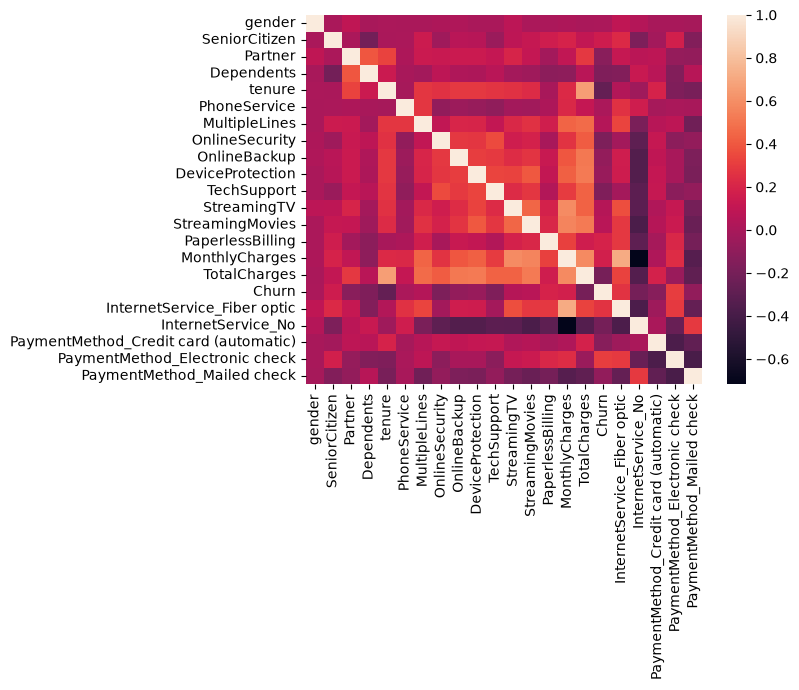

In [94]:
sns.heatmap(df.corr(numeric_only=True))

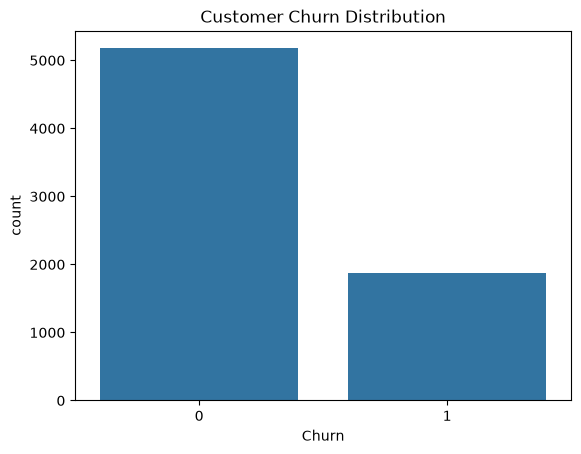

In [95]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

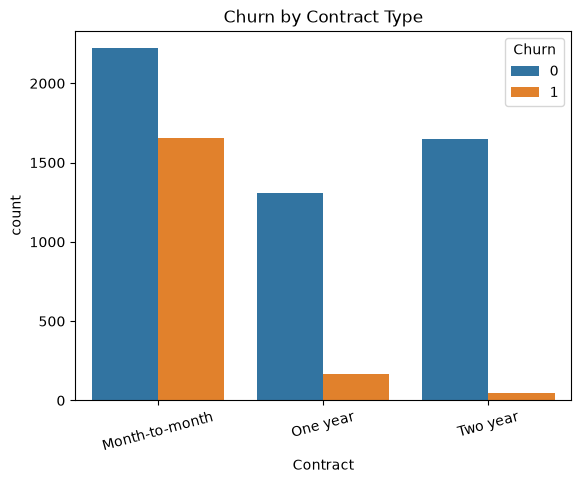

In [96]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

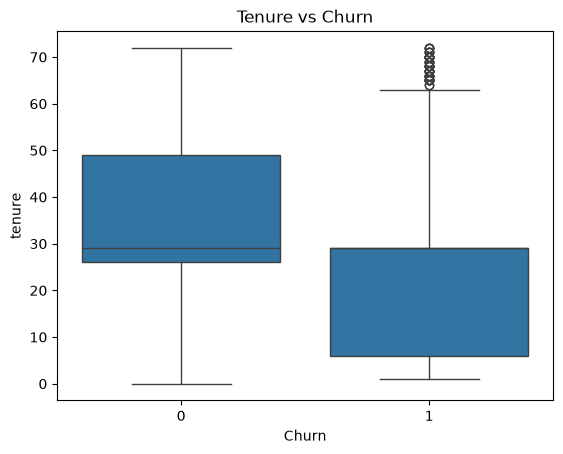

In [103]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

In [114]:
df = df.drop("customerID", axis=1)

In [118]:
df = pd.get_dummies(
    df,
    columns=["Contract"],
    drop_first=True,
    dtype=int
)

In [128]:
print(X.select_dtypes(include="object").columns)
print(X.isna().sum().sum())
print(y.isna().sum())

Index([], dtype='str')
11
0


In [155]:
X = df[
    [
        'gender',
        'SeniorCitizen',
        'Partner',
        'Dependents',
        'tenure',
        'PhoneService',
        'MultipleLines',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'PaperlessBilling',
        'MonthlyCharges',
        'TotalCharges'
    ]
]

y = df["Churn"]

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=100)

In [157]:
X_train.isna().sum()[X_train.isna().sum() > 0]
X = X.fillna(X.median())

In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [159]:
print(X_train.isna().sum().sum())

0


In [174]:
model = LogisticRegression(
    max_iter=1000,
)

In [175]:
print(X.isna().sum()[X.isna().sum() > 0])

Series([], dtype: int64)


In [176]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [177]:
y_pred = model.predict(X_test)

In [178]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7494677075940384


In [179]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[960  76]
 [277  96]]


In [180]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.78      0.93      0.84      1036
           1       0.56      0.26      0.35       373

    accuracy                           0.75      1409
   macro avg       0.67      0.59      0.60      1409
weighted avg       0.72      0.75      0.71      1409



In [182]:
df = df.loc[:, ~df.columns.duplicated()]

In [183]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_Fiber optic', 'InternetService_No',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_One year', 'Contract_Two year'],
      dtype='str')

In [184]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [185]:
print("Object columns:")
print(X.select_dtypes(include="object").columns)

print("\nMissing values:")
print(X.isna().sum().sum())

print("\nDuplicate columns:")
print(X.columns[X.columns.duplicated()])

Object columns:
Index([], dtype='str')

Missing values:
11

Duplicate columns:
Index([], dtype='str')


In [188]:
X = X.fillna(X.median())

In [189]:
print("\nMissing values:")
print(X.isna().sum().sum())


Missing values:
0


In [190]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [191]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

C:\Users\Mayur More\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [192]:
y_pred = model.predict(X_test)

In [193]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7459190915542938


In [195]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[769 267]
 [ 91 282]]


In [197]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1036
           1       0.51      0.76      0.61       373

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



<Axes: >

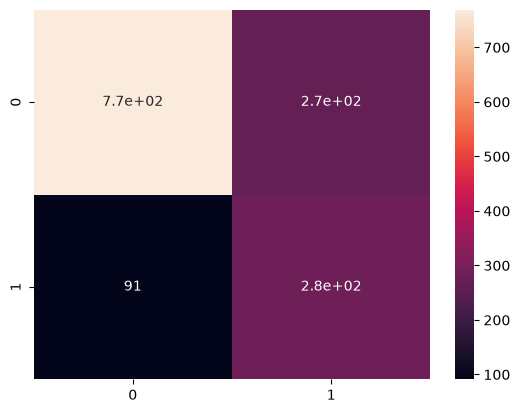

In [199]:
sns.heatmap(cm, annot = True)